In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/uber-ride-analytics-dashboard/ncr_ride_bookings.csv
/kaggle/input/uber-ride-analytics-dashboard/Dasboard.gif
/kaggle/input/uber-ride-analytics-dashboard/Uber.pbix


In [2]:
df=pd.read_csv("/kaggle/input/uber-ride-analytics-dashboard/ncr_ride_bookings.csv")
df.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [3]:
df.shape

(150000, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [5]:
df.describe().sum()


Avg VTAT                       139559.129916
Avg CTAT                       102180.252214
Cancelled Rides by Customer     10506.000000
Cancelled Rides by Driver       27006.000000
Incomplete Rides                 9006.000000
Booking Value                  108568.101686
Ride Distance                  102162.639150
Driver Ratings                  93025.667864
Customer Rating                 93026.342403
dtype: float64

In [6]:
df.isnull().values.sum()


1123500

In [7]:
df[df.duplicated()]


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method


In [8]:
df.duplicated().sum()

0

In [9]:
df.isnull().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [10]:
df=pd.DataFrame(df)

In [11]:
df["Cancelled Rides by Customer"].value_counts()

Cancelled Rides by Customer
1.0    10500
Name: count, dtype: int64

In [12]:
df["Cancelled Rides by Customer"].dropna()

18        1.0
39        1.0
46        1.0
62        1.0
78        1.0
         ... 
149943    1.0
149952    1.0
149956    1.0
149963    1.0
149965    1.0
Name: Cancelled Rides by Customer, Length: 10500, dtype: float64

In [13]:
print(df["Cancelled Rides by Customer"].value_counts())

Cancelled Rides by Customer
1.0    10500
Name: count, dtype: int64


In [14]:
df=df[df["Cancelled Rides by Customer"]!=1.5]

In [15]:
df["Cancelled Rides by Customer"].value_counts()

Cancelled Rides by Customer
1.0    10500
Name: count, dtype: int64

In [16]:
df.sample(3)

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
64723,2024-09-10,00:32:21,"""CNR1794568""",Completed,"""CID5359585""",Auto,Chandni Chowk,Vidhan Sabha,6.3,16.9,...,NaN,NaN,NaN,NaN,NaN,125.0,44.55,4.3,4.7,Debit Card
92713,2024-11-18,05:51:48,"""CNR2445276""",Completed,"""CID6474917""",Go Sedan,Pulbangash,Sarojini Nagar,3.8,33.3,...,NaN,NaN,NaN,NaN,NaN,323.0,13.75,3.8,4.2,UPI
94577,2024-04-29,09:54:08,"""CNR1424954""",Cancelled by Customer,"""CID6257663""",Go Sedan,Pragati Maidan,Hauz Rani,18.3,NaN,...,AC is not working,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
df.isna().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [18]:
df.describe()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000


In [19]:
df["Payment Method"] = df["Payment Method"].fillna("Other")

In [20]:
df["Payment Method"].value_counts()

Payment Method
Other          48000
UPI            45909
Cash           25367
Uber Wallet    12276
Credit Card    10209
Debit Card      8239
Name: count, dtype: int64

In [21]:
df["Cancelled Rides by Driver"].value_counts()

Cancelled Rides by Driver
1.0    27000
Name: count, dtype: int64

In [22]:
df["Cancelled Rides by Driver"]=df["Cancelled Rides by Driver"].fillna("Others")

In [23]:
df["Cancelled Rides by Driver"].value_counts()

Cancelled Rides by Driver
Others    123000
1.0        27000
Name: count, dtype: int64

In [24]:
df["Incomplete Rides"].isnull().sum()

141000

In [25]:
df["Incomplete Rides"].value_counts()

Incomplete Rides
1.0    9000
Name: count, dtype: int64

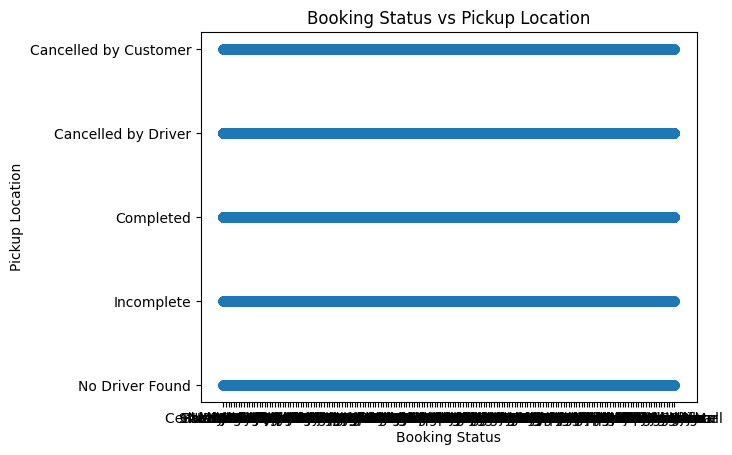

In [26]:
import matplotlib.pyplot as plt

plt.scatter(df["Pickup Location"],df["Booking Status"])
plt.xlabel("Booking Status")
plt.ylabel("Pickup Location")
plt.title("Booking Status vs Pickup Location")
plt.show()

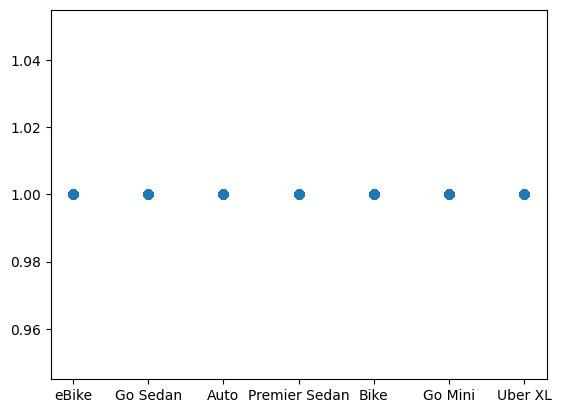

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.scatter(x=df["Vehicle Type"],y=df["Incomplete Rides"])
plt.show()

<Axes: xlabel='Payment Method', ylabel='count'>

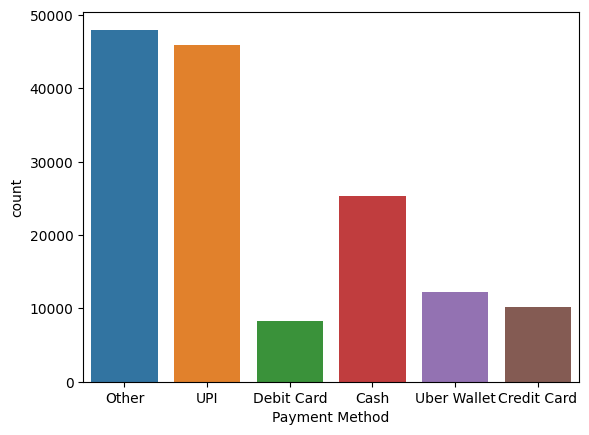

In [28]:
sns.countplot(x=df["Payment Method"])

<Axes: xlabel='Booking Status', ylabel='count'>

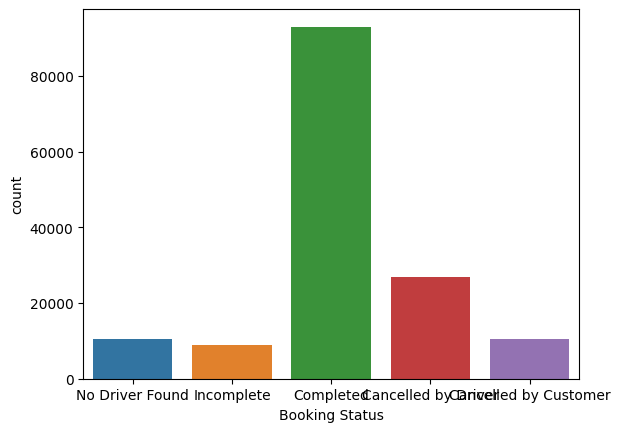

In [29]:
sns.countplot(x=df["Booking Status"])

<Axes: xlabel='Vehicle Type', ylabel='count'>

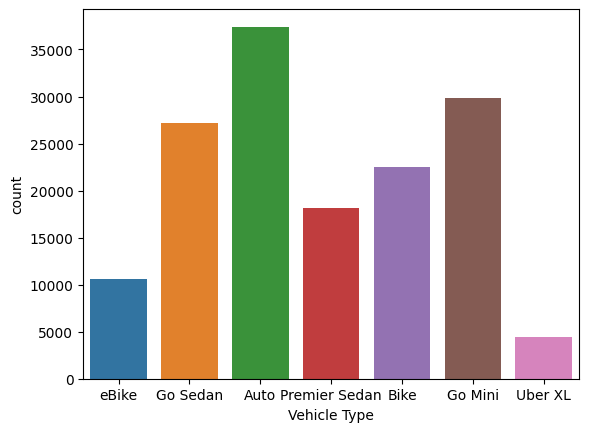

In [30]:
sns.countplot(x=df["Vehicle Type"])

<Axes: xlabel='Drop Location', ylabel='count'>

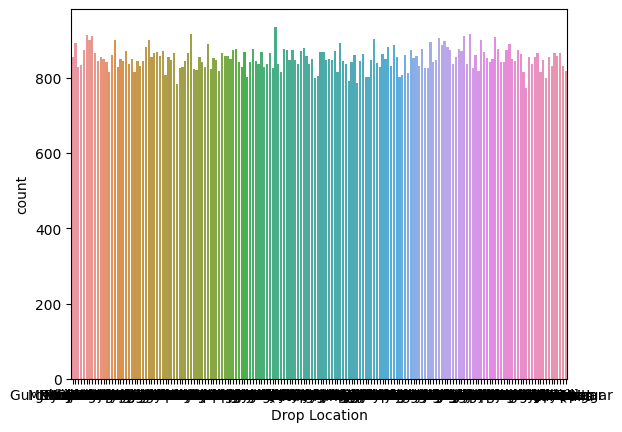

In [31]:
sns.countplot(x=df["Drop Location"])

<Axes: xlabel='Driver Ratings', ylabel='count'>

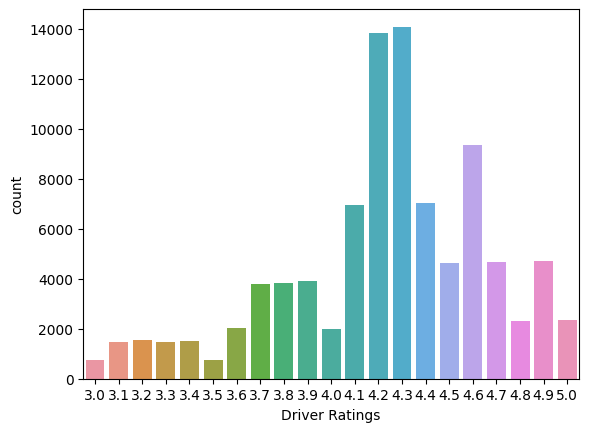

In [32]:
sns.countplot(x=df["Driver Ratings"])

<Axes: xlabel='Customer Rating', ylabel='count'>

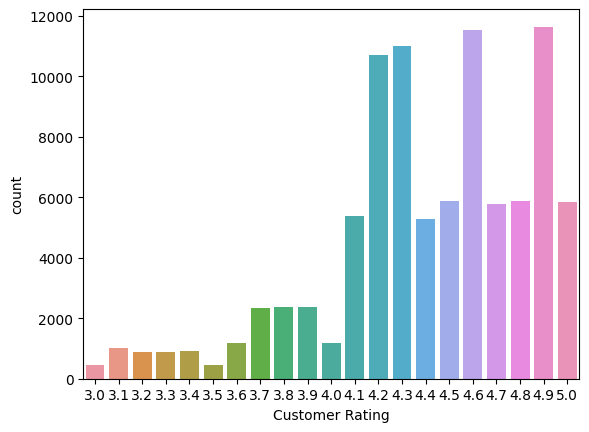

In [33]:
sns.countplot(x=df["Customer Rating"])

([<matplotlib.patches.Wedge at 0x7a0d1519c250>,
 [Text(0.7791358833935688, 0.7764967966505228, 'Auto'),
  Text(-0.6399105877479014, 0.8947147253108868, 'Go Mini'),
  Text(-1.067745680400635, -0.26442231748811423, 'Go Sedan'),
  Text(-0.3124389559342832, -1.0546951686694575, 'Bike'),
  Text(0.5870149243792421, -0.9302760227782035, 'Premier Sedan'),
  Text(1.009941366280317, -0.4359110421586574, 'eBike'),
  Text(1.0952281083644093, -0.10234935587739566, 'Uber XL')],
 [Text(0.42498320912376475, 0.4235437072639215, '24.9%'),
  Text(-0.3490421387715826, 0.4880262138059382, '19.9%'),
  Text(-0.5824067347639826, -0.14423035499351683, '18.1%'),
  Text(-0.1704212486914272, -0.575288273819704, '15.0%'),
  Text(0.3201899587523138, -0.5074232851517474, '12.1%'),
  Text(0.5508771088801728, -0.23776965935926764, '7.0%'),
  Text(0.5973971500169505, -0.055826921387670356, '3.0%')])

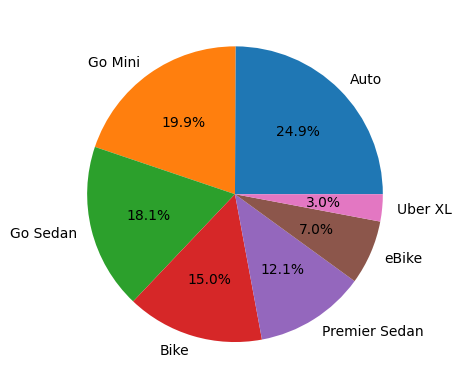

In [37]:
plt.pie(df["Vehicle Type"].value_counts(), 
        labels=df["Vehicle Type"].value_counts().index, 
        autopct='%1.1f%%')

In [34]:
# 1. Git setup
!git config --global user.email "youremail@example.com"
!git config --global user.name "yourgithubusername"

# 2. Repo clone karo (token ke sath)
!git clone https://<TOKEN>@github.com/username/reponame.git

# 3. Apna notebook ya file copy karo repo me
!cp /kaggle/working/YourNotebook.ipynb reponame/

# 4. Push changes
%cd reponame
!git add .
!git commit -m "Added Kaggle notebook"
!git push origin main


/bin/bash: line 1: TOKEN: No such file or directory
cp: cannot stat '/kaggle/working/YourNotebook.ipynb': No such file or directory
[Errno 2] No such file or directory: 'reponame'
/kaggle/working
fatal: not a git repository (or any parent up to mount point /kaggle)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).
fatal: not a git repository (or any parent up to mount point /kaggle)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).
fatal: not a git repository (or any parent up to mount point /kaggle)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).
